In [275]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
import seaborn as sns
import matplotlib.pyplot as plt

In [276]:
df=pd.read_csv("C:\\Users\\HARSHITA\\Downloads\\ecommerce_customer_churn_dataset - ecommerce_customer_churn_dataset.csv")
df.head(2)

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4


In [277]:
df.isnull().mean()*100

Age                               4.990
Gender                            0.000
Country                           0.000
City                              0.000
Membership_Years                  0.000
Login_Frequency                   0.000
Session_Duration_Avg              6.798
Pages_Per_Session                 6.000
Cart_Abandonment_Rate             0.000
Wishlist_Items                    8.000
Total_Purchases                   0.000
Average_Order_Value               0.000
Days_Since_Last_Purchase          6.000
Discount_Usage_Rate               7.000
Returns_Rate                      8.982
Email_Open_Rate                   5.056
Customer_Service_Calls            0.336
Product_Reviews_Written           7.000
Social_Media_Engagement_Score    12.000
Mobile_App_Usage                 10.000
Payment_Method_Diversity          5.000
Lifetime_Value                    0.000
Credit_Balance                   11.000
Churned                           0.000
Signup_Quarter                    0.000


In [278]:
cols=[val for val in df.columns if df[val].isnull().mean()<0.50 and df[val].isnull().mean()>0]
cols

['Age',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Wishlist_Items',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Credit_Balance']

In [279]:
len(df[cols].dropna())/len(df)

0.35966

In [280]:
new_df=df[cols].dropna()
df.shape,new_df.shape

((50000, 25), (17983, 14))

<Axes: >

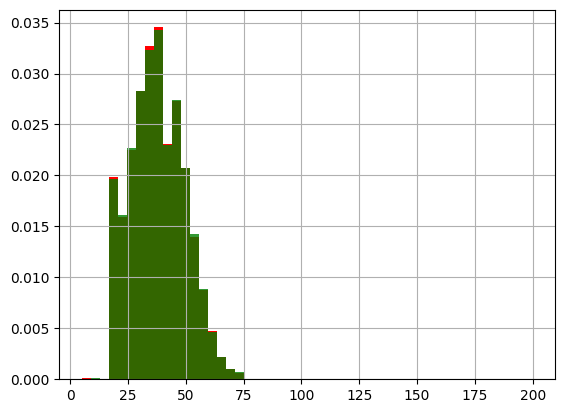

In [281]:
fig=plt.figure()
ax=fig.add_subplot(111)

df['Age'].hist(bins=50,ax=ax,density=True,color='Red')

new_df['Age'].hist(bins=50,ax=ax,color='green',density=True,alpha=0.8)

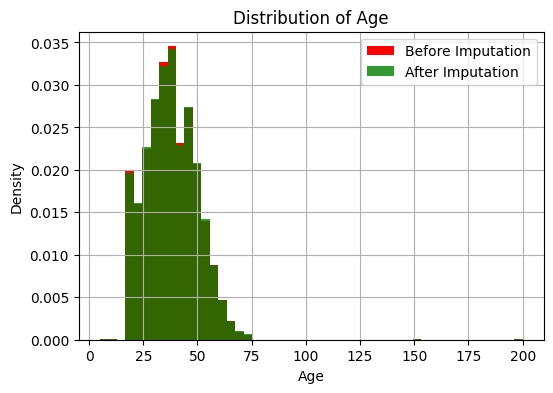

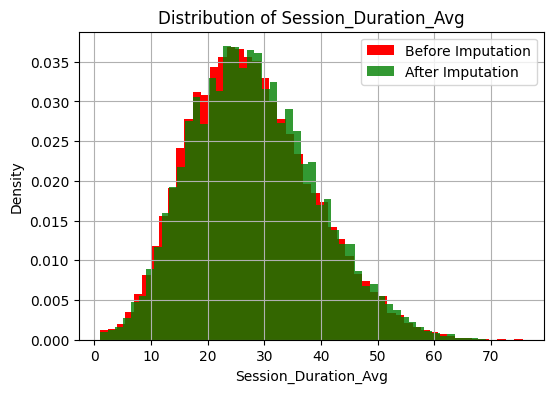

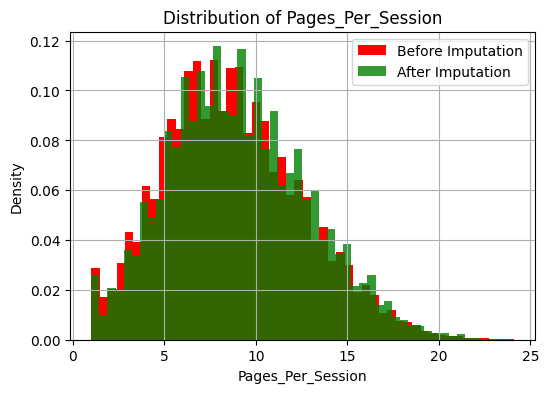

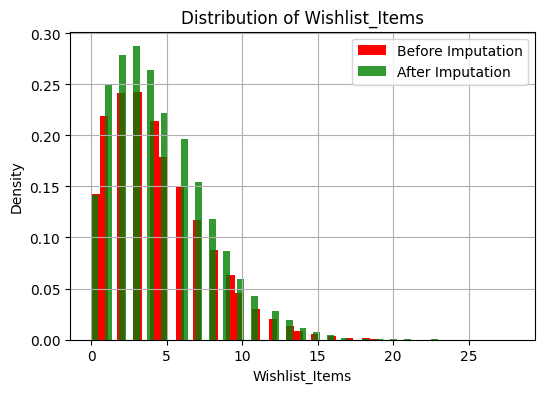

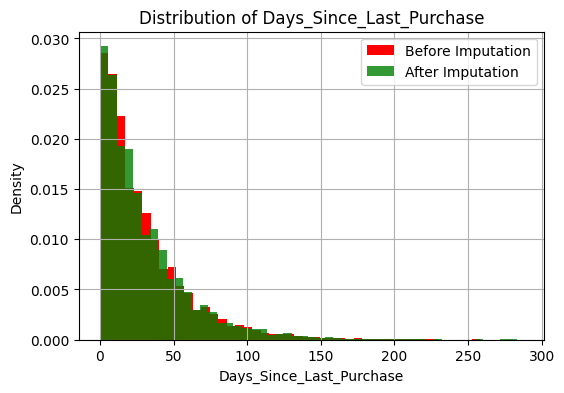

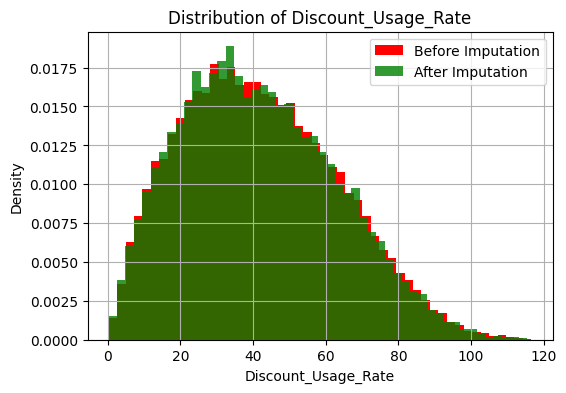

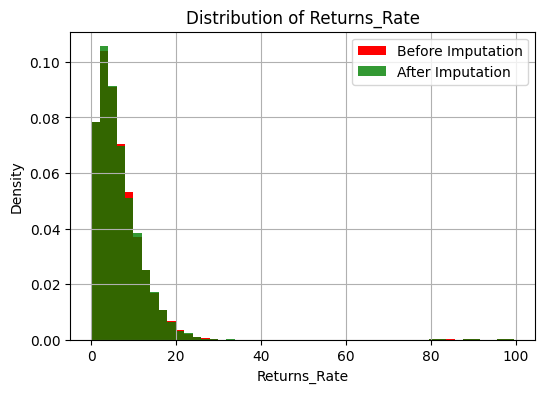

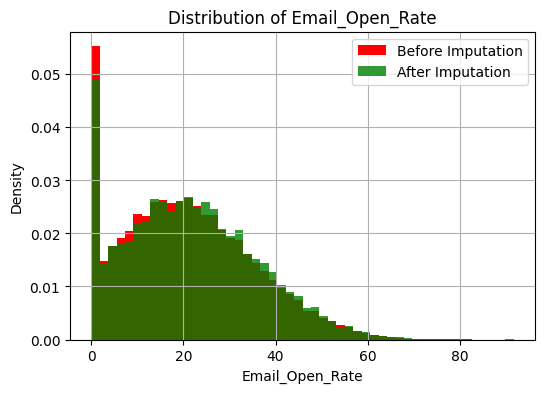

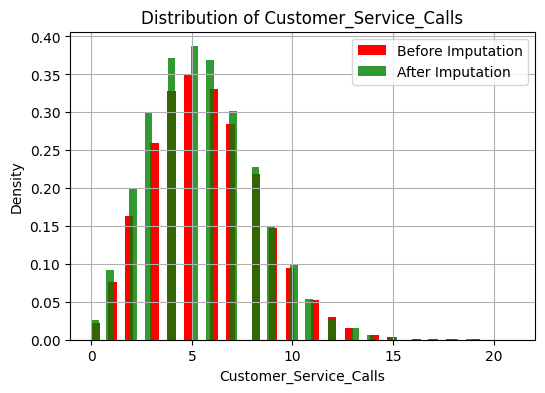

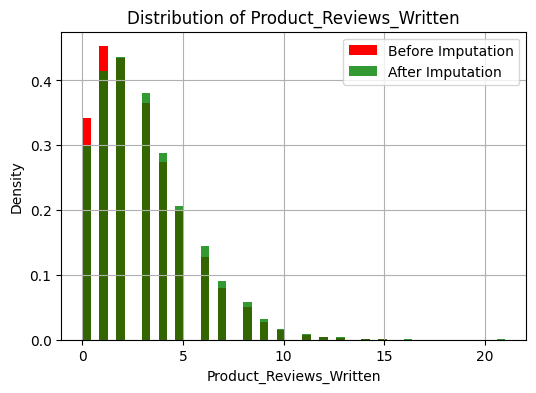

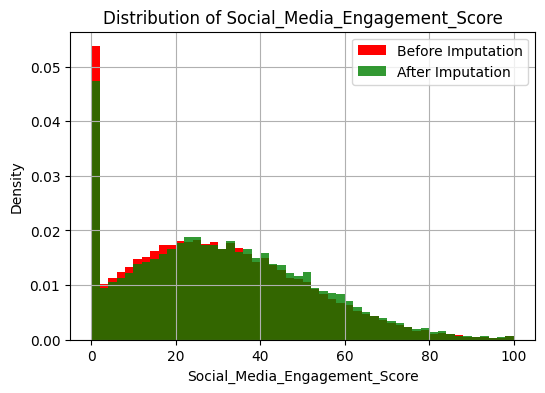

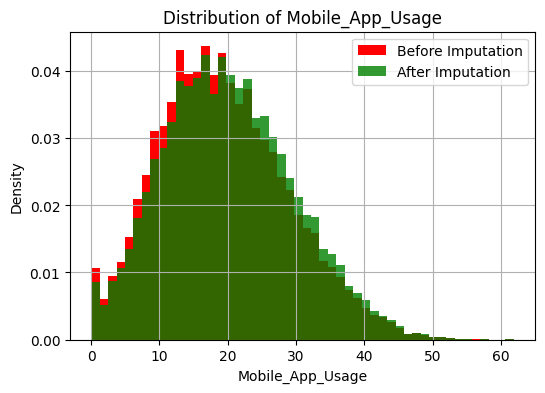

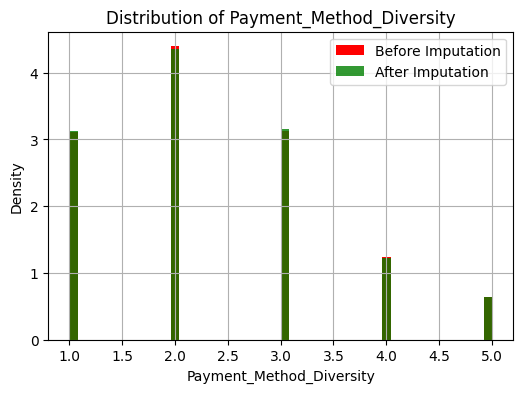

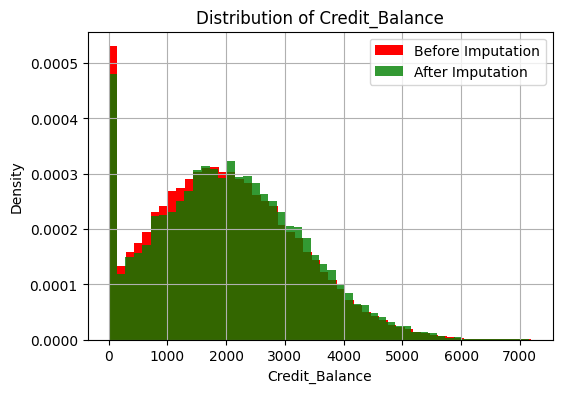

In [282]:
for col in cols:
    plt.figure(figsize=(6,4))
    
    
    df[col].hist(bins=50,density=True,label='Before Imputation',color='Red'
    )
    
    new_df[col].hist(bins=50,density=True,alpha=0.8,label='After Imputation',color='green'
    )
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.legend()
    plt.show()

In [283]:
x=df.drop(columns=['Membership_Years'])
y=df['Membership_Years']

In [284]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [285]:
numerical_col=x_train.select_dtypes(exclude=['object'])
numerical_col

,Age,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
39087,25.0,19,49.1,17.1,20.7,8.0,18.0,134.84,11.0,22.90,11.6,52.1,2.0,1.0,53.3,37.8,3.0,2204.14,3762.0,0
30893,33.0,16,33.7,11.0,55.8,NaN,23.0,198.50,75.0,NaN,7.7,36.6,6.0,NaN,33.5,29.3,2.0,5301.61,3345.0,1
45278,32.0,4,18.4,1.0,71.8,1.0,7.0,76.53,49.0,NaN,15.5,0.2,10.0,2.0,8.0,17.2,2.0,552.31,2728.0,1
16398,48.0,20,45.5,15.9,41.7,9.0,29.9,125.47,1.0,77.88,2.0,49.6,3.0,6.0,28.0,29.2,2.0,2789.64,2077.0,0
13653,35.0,10,18.7,3.1,78.8,0.0,5.0,126.79,6.0,69.70,3.7,25.2,6.0,0.0,12.5,26.3,2.0,740.02,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,30.0,15,39.7,NaN,30.6,9.0,36.4,91.46,12.0,85.08,NaN,20.5,2.0,1.0,62.5,29.3,3.0,2943.35,2129.0,0
44732,29.0,0,11.8,1.3,94.8,NaN,3.0,215.22,60.0,NaN,2.7,0.0,7.0,0.0,0.0,NaN,2.0,637.08,761.0,1
38158,32.0,9,41.7,10.3,47.2,NaN,22.0,63.33,50.0,7.20,3.4,37.2,5.0,1.0,60.7,NaN,3.0,1343.25,1728.0,0
860,40.0,6,NaN,10.1,79.1,2.0,9.0,135.92,25.0,11.70,3.3,11.1,10.0,4.0,52.6,NaN,1.0,1329.58,1325.0,0


In [286]:
categorical_col=df.select_dtypes(include=['object'])
categorical_col

,Gender,Country,City,Signup_Quarter
0,Male,France,Marseille,Q1
1,Male,UK,Manchester,Q4
2,Female,Canada,Vancouver,Q4
3,Female,USA,New York,Q1
4,Male,India,Delhi,Q4
...,...,...,...,...
49995,Female,USA,Los Angeles,Q2
49996,Male,USA,Chicago,Q3
49997,Female,USA,Phoenix,Q1
49998,Female,USA,Chicago,Q2


In [287]:
df.isnull().sum()

Age                              2495
Gender                              0
Country                             0
City                                0
Membership_Years                    0
Login_Frequency                     0
Session_Duration_Avg             3399
Pages_Per_Session                3000
Cart_Abandonment_Rate               0
Wishlist_Items                   4000
Total_Purchases                     0
Average_Order_Value                 0
Days_Since_Last_Purchase         3000
Discount_Usage_Rate              3500
Returns_Rate                     4491
Email_Open_Rate                  2528
Customer_Service_Calls            168
Product_Reviews_Written          3500
Social_Media_Engagement_Score    6000
Mobile_App_Usage                 5000
Payment_Method_Diversity         2500
Lifetime_Value                      0
Credit_Balance                   5500
Churned                             0
Signup_Quarter                      0
dtype: int64

In [288]:
df=df.dropna()

In [289]:
# Encoding

In [290]:
# 1. Label Encoder

In [291]:
# le=LabelEncoder()

In [292]:
# x_train['Gender']=le.fit_transform(x_train['Gender'])
# x_train['Country']=le.fit_transform(x_train['Country'])
# x_train['City']=le.fit_transform(x_train['City'])
# x_train['Signup_Quarter']=le.fit_transform(x_train['Signup_Quarter'])


In [293]:
# Ordinal Encoder

In [294]:
df['Signup_Quarter'].unique()

array(['Q1', 'Q2', 'Q3', 'Q4'], dtype=object)

In [295]:
oe=OrdinalEncoder(categories=[['Male', 'Female', 'Other'],['France', 'UK', 'Canada', 'USA', 'India', 'Japan', 'Germany',
       'Australia'],['Marseille', 'Manchester', 'Vancouver', 'New York', 'Delhi',
       'Tokyo', 'Berlin', 'Houston', 'Calgary', 'Glasgow', 'Munich',
       'Phoenix', 'Paris', 'Ottawa', 'Los Angeles', 'Bangalore',
       'Adelaide', 'Yokohama', 'Sydney', 'Nagoya', 'Frankfurt', 'Cologne',
       'Hamburg', 'Nice', 'Chicago', 'Toulouse', 'Brisbane', 'Leeds',
       'Mumbai', 'Montreal', 'Melbourne', 'Osaka', 'Lyon', 'Hyderabad',
       'Chennai', 'Birmingham', 'London', 'Toronto', 'Perth', 'Kyoto'],['Q1', 'Q4', 'Q2', 'Q3']])

In [296]:
Ordinal_transformed=oe.fit_transform(x_train[['Gender', 'Country', 'City', 'Signup_Quarter']])

In [297]:
df_new=pd.DataFrame(Ordinal_transformed,columns=categorical_col.columns)

In [298]:
df_new

,Gender,Country,City,Signup_Quarter
0,1.0,2.0,2.0,0.0
1,1.0,2.0,13.0,3.0
2,1.0,4.0,4.0,2.0
3,0.0,1.0,9.0,1.0
4,0.0,3.0,11.0,0.0
...,...,...,...,...
39995,1.0,3.0,11.0,1.0
39996,1.0,2.0,2.0,2.0
39997,1.0,0.0,0.0,2.0
39998,1.0,1.0,27.0,3.0


In [299]:
df_1=pd.concat((numerical_col,df_new),axis=1)

In [300]:
# Standard Scaler

In [301]:
from sklearn.preprocessing import StandardScaler

In [302]:
sc=StandardScaler()

In [303]:
df_sc=sc.fit_transform(df_1)

In [304]:
df_2=pd.DataFrame(df_sc,columns=df_1.columns)

In [305]:
np.round(df_2.describe(),2)

,Age,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Gender,Country,City,Signup_Quarter
count,38016.00,40000.00,37286.00,37603.00,40000.00,36784.00,40000.00,40000.00,37573.00,37211.00,36414.00,38010.00,39863.00,37199.00,35174.00,35995.00,37990.00,40000.00,35605.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,-0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.75,-1.49,-2.45,-2.05,-3.50,-1.35,-3.55,-0.56,-1.01,-1.95,-1.09,-1.47,-2.12,-1.22,-1.43,-2.06,-1.22,-1.59,-1.61,-0.64,-1.01,-1.59,-1.54,-1.34
25%,-0.74,-0.72,-0.73,-0.72,-0.65,-0.72,-0.73,-0.21,-0.70,-0.78,-0.62,-0.77,-0.63,-0.79,-0.79,-0.72,-0.32,-0.72,-0.75,-0.64,-1.01,-0.57,-0.92,-1.34
50%,0.01,-0.08,-0.09,-0.09,0.06,-0.09,-0.16,-0.06,-0.30,-0.09,-0.21,-0.09,-0.25,-0.36,-0.08,-0.08,-0.32,-0.22,-0.06,-0.64,0.87,-0.07,-0.30,0.45
75%,0.69,0.69,0.65,0.65,0.71,0.53,0.56,0.12,0.38,0.70,0.39,0.66,0.49,0.50,0.67,0.64,0.58,0.48,0.67,1.57,0.87,0.44,0.85,1.34
max,13.60,4.40,4.41,4.07,5.25,7.43,16.55,54.90,8.53,3.49,15.18,4.97,5.72,7.81,3.43,4.52,2.38,7.28,4.10,1.57,2.74,1.96,1.92,1.34


In [306]:
df=pd.read_csv("C:\\Users\\HARSHITA\\Downloads\\ecommerce_customer_churn_dataset - ecommerce_customer_churn_dataset.csv")

In [307]:
x=df.drop(columns=['Membership_Years'])
y=df['Membership_Years']

In [308]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [309]:
numerical_col=x_train.select_dtypes(exclude=['object'])
numerical_col

,Age,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
39087,25.0,19,49.1,17.1,20.7,8.0,18.0,134.84,11.0,22.90,11.6,52.1,2.0,1.0,53.3,37.8,3.0,2204.14,3762.0,0
30893,33.0,16,33.7,11.0,55.8,NaN,23.0,198.50,75.0,NaN,7.7,36.6,6.0,NaN,33.5,29.3,2.0,5301.61,3345.0,1
45278,32.0,4,18.4,1.0,71.8,1.0,7.0,76.53,49.0,NaN,15.5,0.2,10.0,2.0,8.0,17.2,2.0,552.31,2728.0,1
16398,48.0,20,45.5,15.9,41.7,9.0,29.9,125.47,1.0,77.88,2.0,49.6,3.0,6.0,28.0,29.2,2.0,2789.64,2077.0,0
13653,35.0,10,18.7,3.1,78.8,0.0,5.0,126.79,6.0,69.70,3.7,25.2,6.0,0.0,12.5,26.3,2.0,740.02,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11284,30.0,15,39.7,NaN,30.6,9.0,36.4,91.46,12.0,85.08,NaN,20.5,2.0,1.0,62.5,29.3,3.0,2943.35,2129.0,0
44732,29.0,0,11.8,1.3,94.8,NaN,3.0,215.22,60.0,NaN,2.7,0.0,7.0,0.0,0.0,NaN,2.0,637.08,761.0,1
38158,32.0,9,41.7,10.3,47.2,NaN,22.0,63.33,50.0,7.20,3.4,37.2,5.0,1.0,60.7,NaN,3.0,1343.25,1728.0,0
860,40.0,6,NaN,10.1,79.1,2.0,9.0,135.92,25.0,11.70,3.3,11.1,10.0,4.0,52.6,NaN,1.0,1329.58,1325.0,0


In [310]:
categorical_col=x_train.select_dtypes(include=['object']).columns
categorical_col

Index(['Gender', 'Country', 'City', 'Signup_Quarter'], dtype='object')

In [311]:
# Outliers Handling

In [312]:
df_before=df.copy()

In [313]:
for col in numerical_col:
    percentile25=df[col].quantile(0.25)
    percentile75=df[col].quantile(0.75)

    IQR=percentile75-percentile25

    upper_limit=percentile75+1.5*IQR
    lower_limit=percentile25-1.5*IQR

    df[col]=np.where(df[col]>upper_limit,upper_limit,
                                np.where(df[col]<lower_limit,lower_limit
                                         ,df[col]))



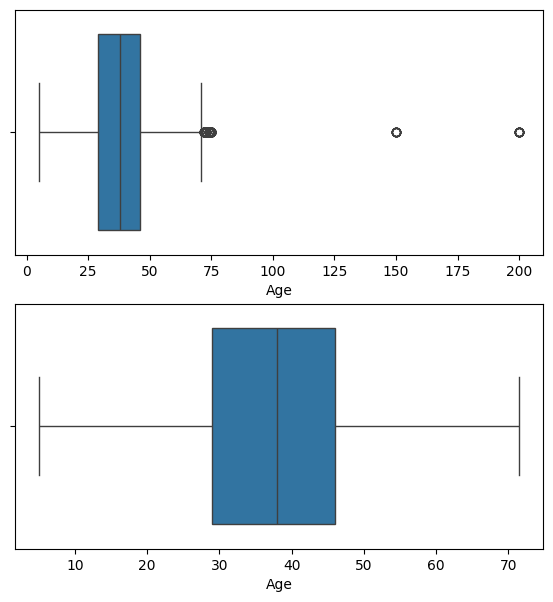

In [314]:
plt.figure(figsize=(15,7))

plt.subplot(222)
sns.boxplot(x=df_before['Age'])


plt.subplot(224)
sns.boxplot(x=df['Age'])

plt.show()


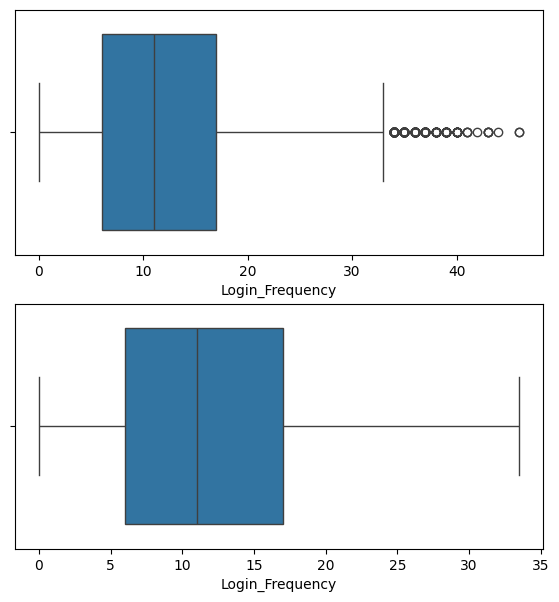

In [315]:
plt.figure(figsize=(15,7))

plt.subplot(222)
sns.boxplot(x=df_before['Login_Frequency'])


plt.subplot(224)
sns.boxplot(x=df['Login_Frequency'])

plt.show()


In [316]:

# column Transformer

In [317]:
transformer=ColumnTransformer(transformers=[
    ('tnf1',SimpleImputer(),['Age',
 'Session_Duration_Avg',
 'Pages_Per_Session',
 'Wishlist_Items',
 'Days_Since_Last_Purchase',
 'Discount_Usage_Rate',
 'Returns_Rate',
 'Email_Open_Rate',
 'Customer_Service_Calls',
 'Product_Reviews_Written',
 'Social_Media_Engagement_Score',
 'Mobile_App_Usage',
 'Payment_Method_Diversity',
 'Credit_Balance']),
    ('tnf2',OrdinalEncoder(),['Gender', 'Country', 'City', 'Signup_Quarter'])
],remainder='passthrough')

In [318]:
transformed=transformer.fit_transform(x_train)

In [319]:
transformed_df=pd.DataFrame(transformed,columns=x_train.columns)

In [320]:
transformed_df.head(2)

,Age,Gender,Country,City,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,25.0,49.1,17.1,8.000000,11.0,22.900000,11.6,52.1,2.0,1.000000,53.3,37.8,3.0,3762.0,0.0,1.0,38.0,0.0,19.0,20.7,18.0,134.84,2204.14,0.0
1,33.0,33.7,11.0,4.301517,75.0,42.016987,7.7,36.6,6.0,2.847792,33.5,29.3,2.0,3345.0,0.0,1.0,30.0,2.0,16.0,55.8,23.0,198.50,5301.61,1.0


In [321]:
# MinMaxScaler

In [322]:
from sklearn.preprocessing import MinMaxScaler

In [323]:
mn=MinMaxScaler()

In [324]:
transformed_df_mn=mn.fit_transform(transformed_df)

In [325]:
ct_df=pd.DataFrame(transformed_df_mn,columns=transformed_df.columns)

In [326]:
np.round(ct_df.describe(),2)

,Age,Gender,Country,City,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
count,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00,40000.00
mean,0.17,0.36,0.33,0.15,0.11,0.36,0.07,0.23,0.27,0.14,0.29,0.31,0.34,0.28,0.26,0.64,0.49,0.50,0.25,0.40,0.18,0.01,0.18,0.29
std,0.06,0.14,0.16,0.11,0.10,0.18,0.06,0.15,0.13,0.11,0.19,0.14,0.27,0.17,0.27,0.36,0.28,0.37,0.17,0.11,0.05,0.02,0.11,0.45
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.13,0.26,0.23,0.07,0.03,0.23,0.03,0.11,0.19,0.05,0.15,0.21,0.25,0.17,0.00,0.29,0.26,0.00,0.13,0.32,0.14,0.01,0.10,0.00
50%,0.17,0.36,0.33,0.14,0.08,0.36,0.06,0.23,0.24,0.14,0.29,0.31,0.25,0.28,0.00,0.71,0.46,0.33,0.24,0.41,0.17,0.01,0.15,0.00
75%,0.21,0.44,0.43,0.21,0.14,0.47,0.09,0.32,0.33,0.19,0.41,0.40,0.50,0.38,0.50,1.00,0.72,0.67,0.37,0.48,0.20,0.01,0.23,1.00
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
